# Simulation Playground Notebook
This notebook is designed as a easy einterface to call the functions that we have defined

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

import torch.optim as optim
import torch.nn as nn
import torch

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_participants_info, load_event_descriptions, load_behavioral_data, preprocess_data

# Data Preparation
Let's prepare some data first to fit our model. We are specifically using ["Locus coeruleus activity strengthens prioritized memories under arousal"](https://openneuro.org/datasets/ds002011/versions/1.0.0) dataset fror now.

In [2]:
DATASET_PATH = "data"
participants_df = load_participants_info(DATASET_PATH)
load_event_descriptions(DATASET_PATH)

df_behavior = load_behavioral_data(DATASET_PATH, "01")
for idx in range(2,11):
    sample_participant = f"0{idx}"
    df = load_behavioral_data(DATASET_PATH, sample_participant)
    df_behavior = pd.concat([df, df_behavior], ignore_index=True)

Let's preprocess our data first

In [3]:
X, Y, X_tensor, Y_tensor, scaler_X, scaler_Y, df_clean = preprocess_data(df_behavior)

X Shape: torch.Size([1699, 7]), Y Shape: torch.Size([1699])
Y Min: -1.0, Y Max: 1.0


In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X_tensor, Y_tensor, test_size=0.2, random_state=42)

# Training

In [5]:
from train import (train_feed_forward_nn,
                   train_vanilla_rnn,
                   train_vanilla_lstm,
                   train_vanilla_lc_model,
                   train_lstm_lc_model,
                   train_ff_controller,
                   train_ff_uncertain_controller
                   )
from analysis.evaluation import evaluate_model

## Fully Connected Neural Network

To illustrate our idea, we want to train 2 models from math and computer science, which is our vanilla feed forward networks and an recurrent networks.

Epoch 0, Loss: 0.2473006248474121
Epoch 100, Loss: 0.05039006099104881
Epoch 200, Loss: 0.048963192850351334
Epoch 300, Loss: 0.047792818397283554
Epoch 400, Loss: 0.04667825996875763
Epoch 500, Loss: 0.04528201371431351
Epoch 600, Loss: 0.04474395513534546
Epoch 700, Loss: 0.04413607344031334
Epoch 800, Loss: 0.04426050931215286
Epoch 900, Loss: 0.04422483965754509
Epoch 1000, Loss: 0.04325562343001366
Epoch 1100, Loss: 0.0429164282977581
Epoch 1200, Loss: 0.04315593093633652
Epoch 1300, Loss: 0.042408328503370285
Epoch 1400, Loss: 0.042500000447034836
Epoch 1500, Loss: 0.04225870966911316
Epoch 1600, Loss: 0.04228993132710457
Epoch 1700, Loss: 0.041611090302467346
Epoch 1800, Loss: 0.04164276644587517
Epoch 1900, Loss: 0.041256751865148544
Training complete!
Evaluating Model: FeedForwardNN


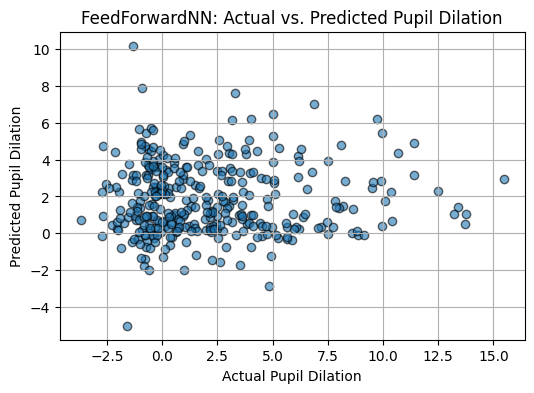

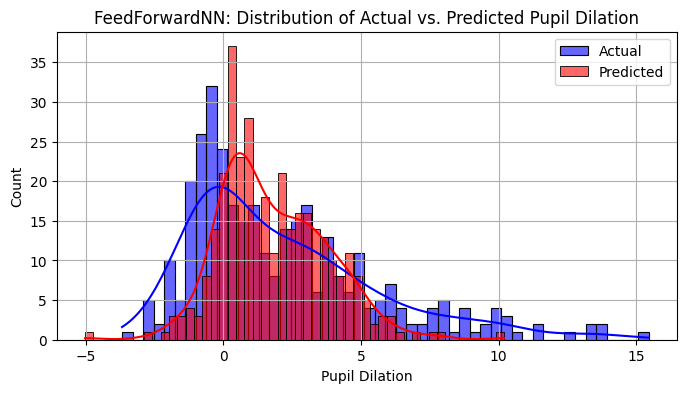

FeedForwardNN - Pearson Correlation: 0.0296


In [6]:
model_ff = train_feed_forward_nn(X_train, Y_train,epochs=2000)
evaluate_model(model_ff, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## Recurent Neural Networks

We will  do the same thing with an recurrent neural network

In [7]:
# model_rnn = train_vanilla_rnn(X_train, Y_train, epochs=2000)
# evaluate_model(model_rnn, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LSTM Models

In [8]:
# model_lstm = train_vanilla_lstm(X_train, Y_train, epochs=5000, hidden_dim=12)
# evaluate_model(model_lstm, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LCNECortex Fitter Model

Now coming to our customized LCNECortex model

Epoch 0, Loss: 0.1657477468252182


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.03271054849028587
Epoch 200, Loss: 0.039683353155851364
Epoch 300, Loss: 0.031449344009160995
Epoch 400, Loss: 0.03203698620200157
Epoch 500, Loss: 0.04316668212413788
Epoch 600, Loss: 0.02315065637230873
Epoch 700, Loss: 0.0573386624455452
Epoch 800, Loss: 0.047543078660964966
Epoch 900, Loss: 0.04328286275267601
Epoch 1000, Loss: 0.034737538546323776
Epoch 1100, Loss: 0.030725868418812752
Epoch 1200, Loss: 0.06030276417732239
Epoch 1300, Loss: 0.040063824504613876
Epoch 1400, Loss: 0.053388696163892746
Epoch 1500, Loss: 0.04465741291642189
Epoch 1600, Loss: 0.0726526752114296
Epoch 1700, Loss: 0.04105711728334427
Epoch 1800, Loss: 0.02503110095858574
Epoch 1900, Loss: 0.03619853034615517
Training complete!
Evaluating Model: LCNECortexFitter


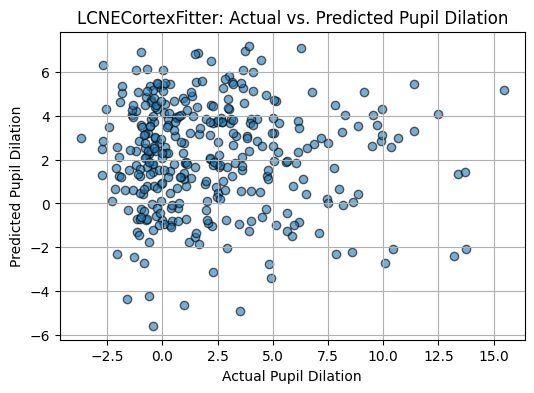

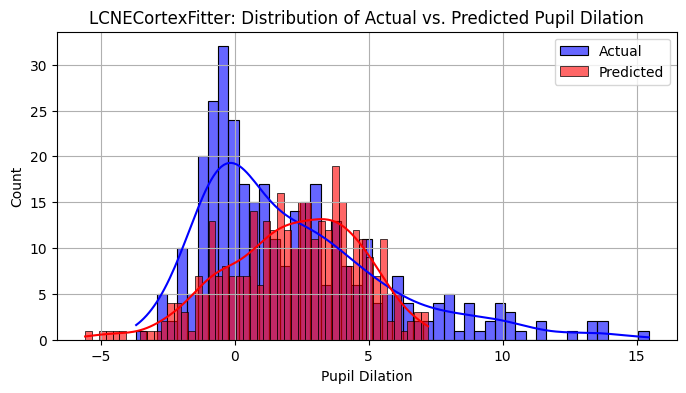

LCNECortexFitter - Pearson Correlation: -0.0264


In [9]:
model_lc_vanilla = train_vanilla_lc_model(X_train, Y_train, epochs=2000)
evaluate_model(model_lc_vanilla, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LSTM LCNECortex Model

In [10]:
# model_lc_lstm = train_lstm_lc_model(X_train, Y_train, epochs=2000, hidden_dim=64)
# evaluate_model(model_lc_lstm, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

# FF Gadget Model

Epoch 0, Loss: 0.095051


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.009805
Epoch 200, Loss: 0.038134
Epoch 300, Loss: 0.021378
Epoch 400, Loss: 0.027353
Epoch 500, Loss: 0.018838
Epoch 600, Loss: 0.022928
Epoch 700, Loss: 0.021829
Epoch 800, Loss: 0.025268
Epoch 900, Loss: 0.021605
Epoch 1000, Loss: 0.054226
Epoch 1100, Loss: 0.021670
Epoch 1200, Loss: 0.032122
Epoch 1300, Loss: 0.040209
Epoch 1400, Loss: 0.028646
Epoch 1500, Loss: 0.052855
Epoch 1600, Loss: 0.030162
Epoch 1700, Loss: 0.028166
Epoch 1800, Loss: 0.022214
Epoch 1900, Loss: 0.031367
Epoch 2000, Loss: 0.049282
Epoch 2100, Loss: 0.033138
Epoch 2200, Loss: 0.031018
Epoch 2300, Loss: 0.055804
Epoch 2400, Loss: 0.027005
Epoch 2500, Loss: 0.042256
Epoch 2600, Loss: 0.013831
Epoch 2700, Loss: 0.038906
Epoch 2800, Loss: 0.024582
Early stopping triggered at epoch 2834
Training complete!
Evaluating Model: FFGadgetController


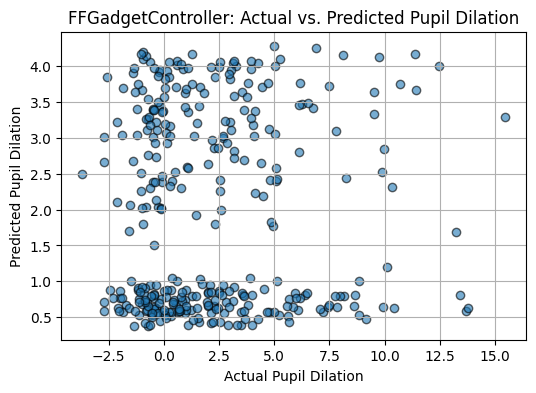

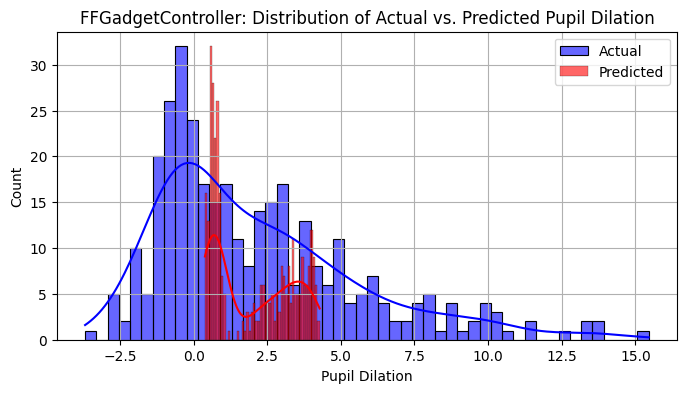

FFGadgetController - Pearson Correlation: 0.0285


In [11]:
ff_gadget = train_ff_controller(X_train, Y_train, epochs=5000, hidden_dim=264)
evaluate_model(ff_gadget, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## Modified Uncertainty GadgetModel

Epoch 0, Loss: 0.045550


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.019186
Epoch 200, Loss: 0.025720
Epoch 300, Loss: 0.023376
Epoch 400, Loss: 0.018212
Epoch 500, Loss: 0.035265
Epoch 600, Loss: 0.015999
Epoch 700, Loss: 0.024033
Epoch 800, Loss: 0.017722
Epoch 900, Loss: 0.029437
Epoch 1000, Loss: 0.031725
Epoch 1100, Loss: 0.016880
Epoch 1200, Loss: 0.026483
Epoch 1300, Loss: 0.030387
Epoch 1400, Loss: 0.033788
Epoch 1500, Loss: 0.045774
Epoch 1600, Loss: 0.022813
Epoch 1700, Loss: 0.026434
Epoch 1800, Loss: 0.020250
Epoch 1900, Loss: 0.015158
Epoch 2000, Loss: 0.021850
Epoch 2100, Loss: 0.017836
Epoch 2200, Loss: 0.029970
Epoch 2300, Loss: 0.016449
Epoch 2400, Loss: 0.026479
Epoch 2500, Loss: 0.022714
Epoch 2600, Loss: 0.038075
Epoch 2700, Loss: 0.013520
Epoch 2800, Loss: 0.023012
Epoch 2900, Loss: 0.048352
Epoch 3000, Loss: 0.024676
Epoch 3100, Loss: 0.021196
Epoch 3200, Loss: 0.029460
Epoch 3300, Loss: 0.022032
Epoch 3400, Loss: 0.018714
Epoch 3500, Loss: 0.029784
Epoch 3600, Loss: 0.023162
Epoch 3700, Loss: 0.018865
Epoch 3800

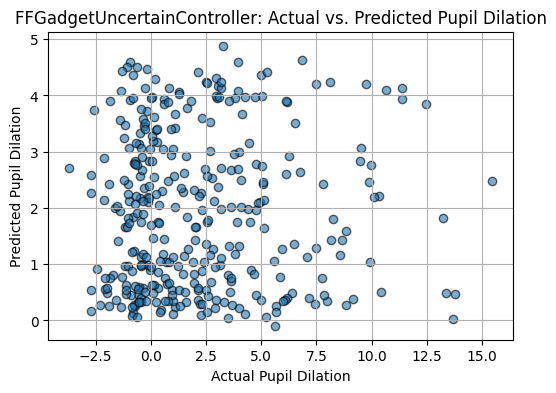

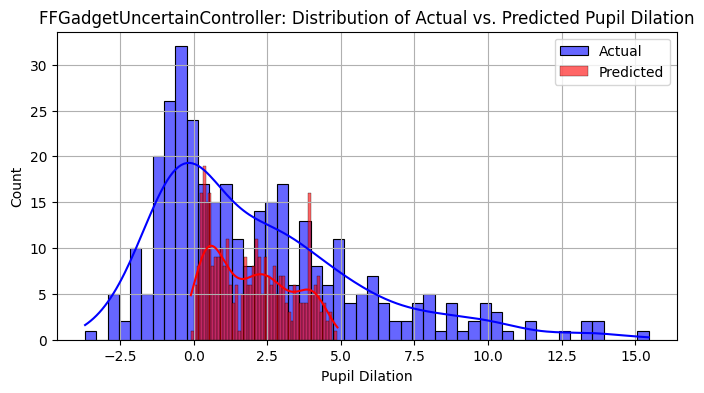

FFGadgetUncertainController - Pearson Correlation: 0.0247


In [12]:
ff_uncertain_gadget = train_ff_uncertain_controller(X_tensor, Y_tensor, epochs=5000, hidden_dim=200)
evaluate_model(ff_uncertain_gadget, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

# Analysis

In [13]:
from analysis.analysis import (pca_lcne_lstm,
                               pca_feed_forward,
                               pca_lcne,
                               pca_lstm,
                               analyze_ff_gadget_activations,
                               evaluate_ff_uncertainty_gadget
)

## Feed-Forward Neural Networks

In [14]:
# pca_feed_forward(model_ff, X_tensor, df_behavior)

## LCNECortex Model

We will see that, though  under fitted with the real data, there are some structureness to the data that we can play around with since we injected mechanistic insights into it.

Text(0.5, 1.0, 'Cortex Activation Distribution')

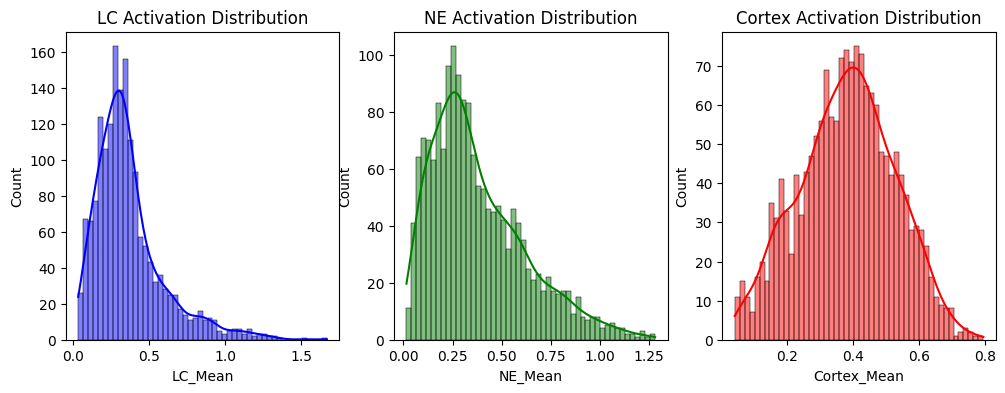

In [15]:
with torch.no_grad():
    prev_LC = torch.zeros(X_tensor.shape[0], model_lc_vanilla.hidden_dim)
    prev_Cortex = torch.zeros(X_tensor.shape[0], model_lc_vanilla.hidden_dim)

    LC_act, NE_act, C_act, Pupil_pred, LC_raw, NE_raw, C_raw = model_lc_vanilla(X_tensor, prev_LC, prev_Cortex, return_activations=True)

act_lc = LC_act.cpu().numpy()
act_ne = NE_act.cpu().numpy()
act_cortex = C_act.cpu().numpy()

df_activations = pd.DataFrame({
    'LC_Mean': act_lc.mean(axis=1),
    'NE_Mean': act_ne.mean(axis=1),
    'Cortex_Mean': act_cortex.mean(axis=1),
    'PupilPred': Pupil_pred.cpu().numpy().squeeze(),
    'ActualPupil': df_clean['Event_PupilDilation'].values  # Ensure this aligns with X_tensor
})

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(df_activations['LC_Mean'], kde=True, bins=50, color='blue')
plt.title("LC Activation Distribution")

plt.subplot(1, 3, 2)
sns.histplot(df_activations['NE_Mean'], kde=True, bins=50, color='green')
plt.title("NE Activation Distribution")

plt.subplot(1, 3, 3)
sns.histplot(df_activations['Cortex_Mean'], kde=True, bins=50, color='red')
plt.title("Cortex Activation Distribution")

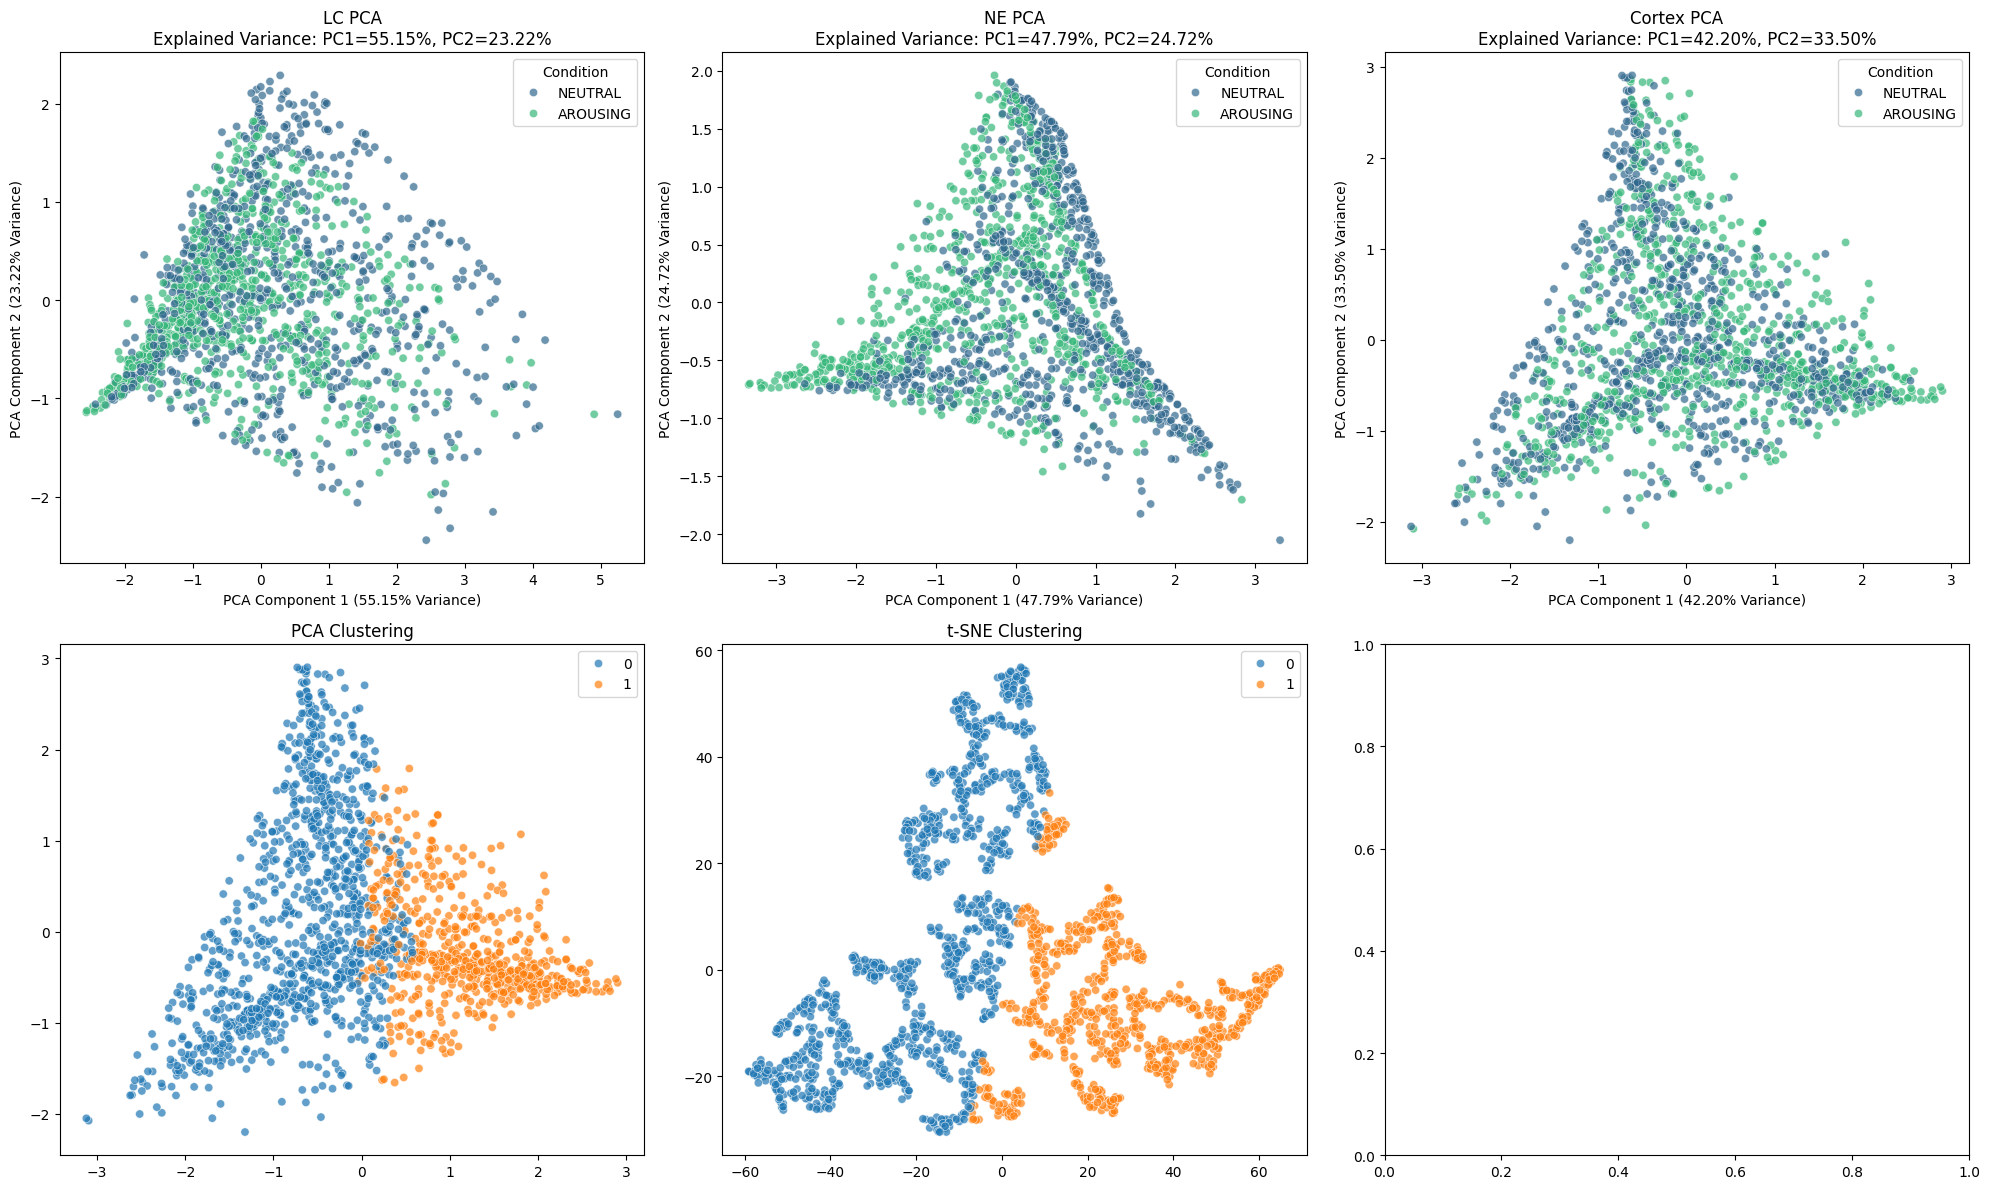

In [16]:
pca_lcne(model_lc_vanilla, X_tensor, df_clean)

## LSTM LCNECortex Model

In [17]:
# pca_lcne_lstm(model_lc_lstm, X_tensor, df_clean)

## Vanilla LSTM Comparison

In [18]:
# pca_lstm(model_lstm, X_test, df_clean)

## FF Gadget Model

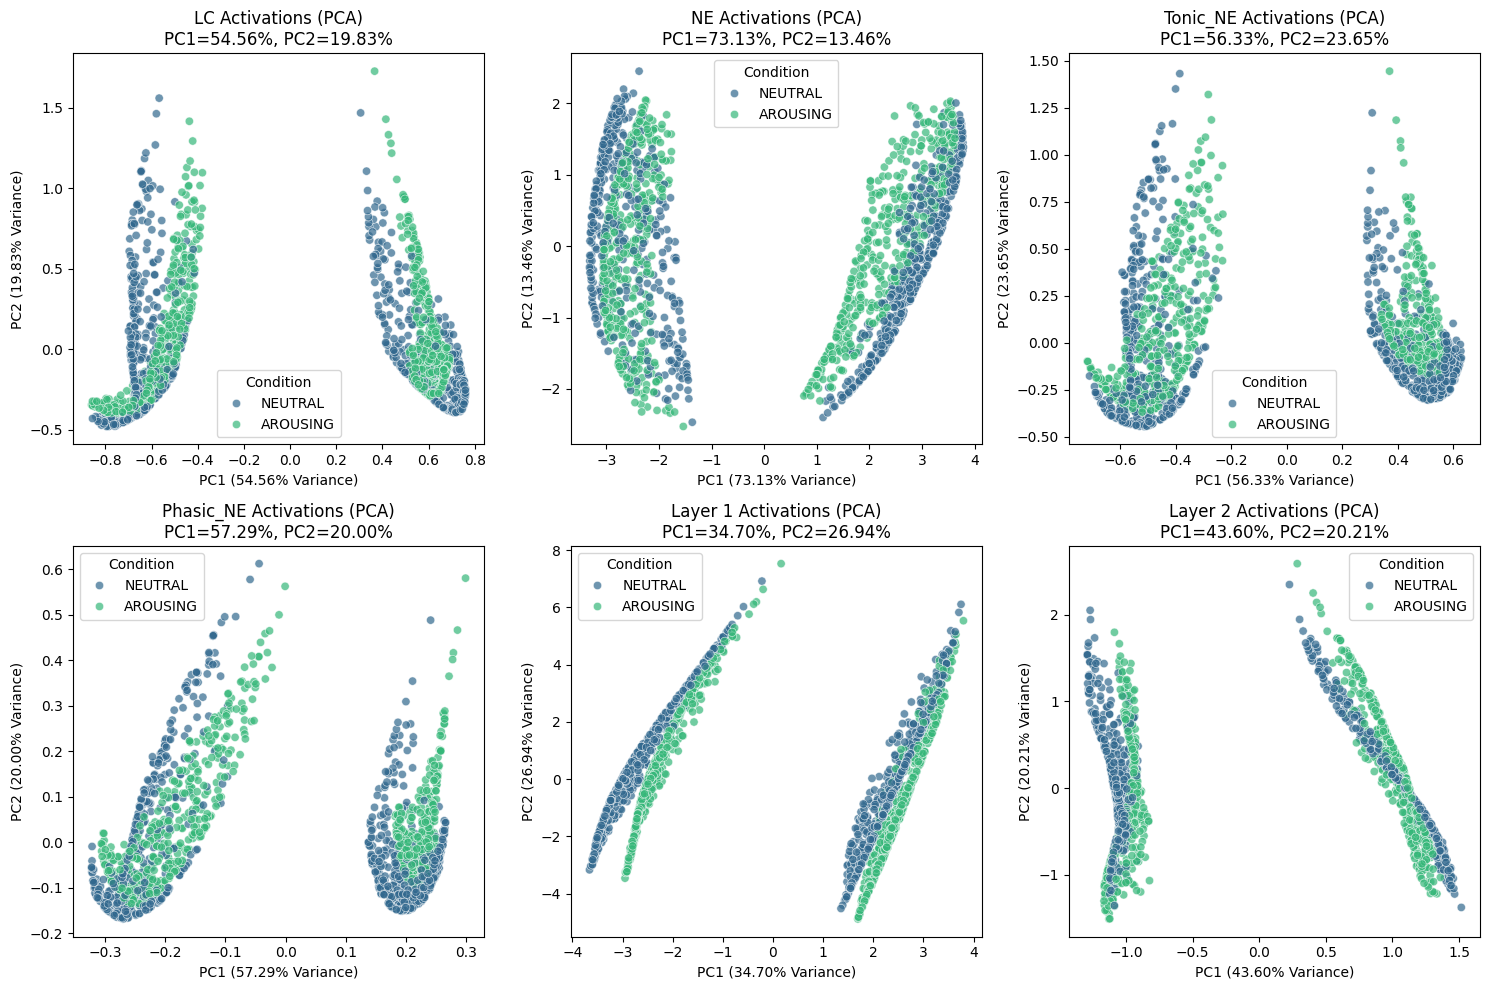

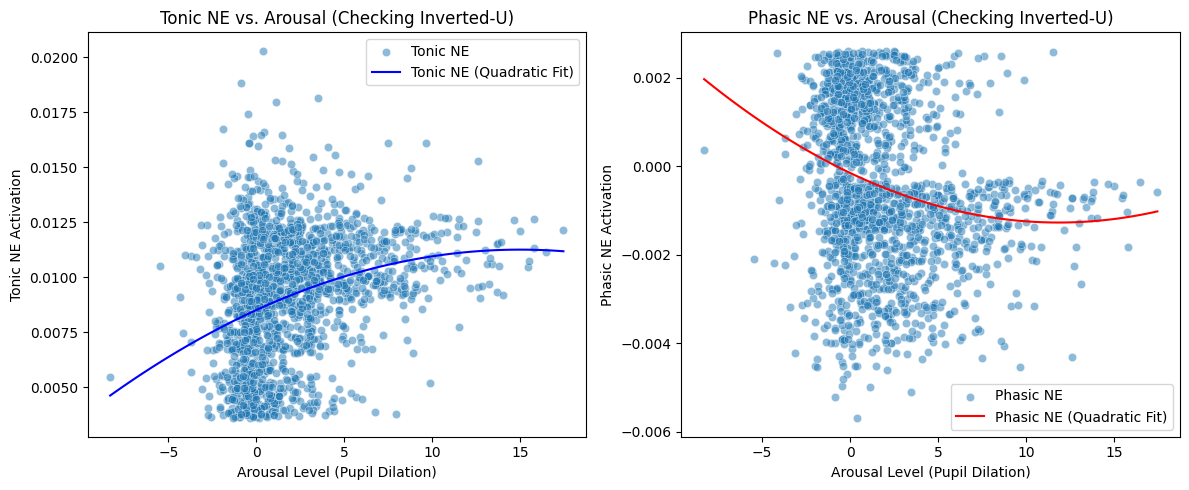


 Pearson Correlation with Actual Pupil Dilation:
LC: 0.244
NE: -0.354
Tonic_NE: 0.300
Phasic_NE: -0.216
Layer 1: -0.070
Layer 2: 0.061
Predicted Pupil Dilation: 0.436


In [19]:
analyze_ff_gadget_activations(ff_gadget, X_tensor, df_clean)

This model elarning representation is quite unstable

## Modified Uncertainty GadgetModel

Pupil Dilation MAE: 2.2109
Pupil Dilation MSE: 8.4710


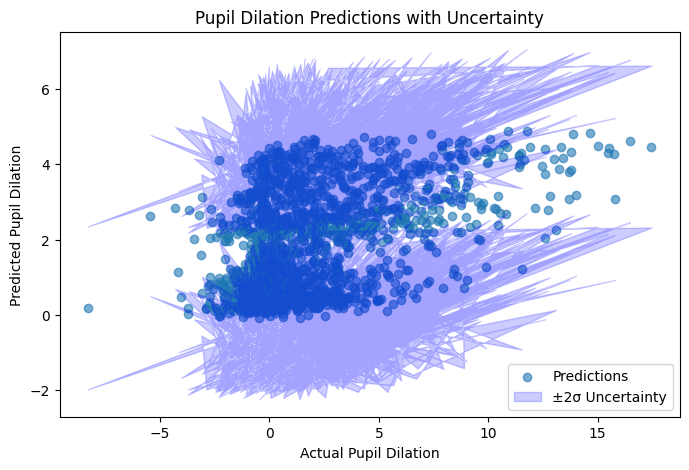

In [20]:
evaluate_ff_uncertainty_gadget(ff_uncertain_gadget, X_tensor, Y_tensor, scaler_Y)

In [21]:
from analysis.analysis import (extract_activations,
                               compute_mapper_graph,
                               compute_persistent_homology)

Analyzing LC activations...


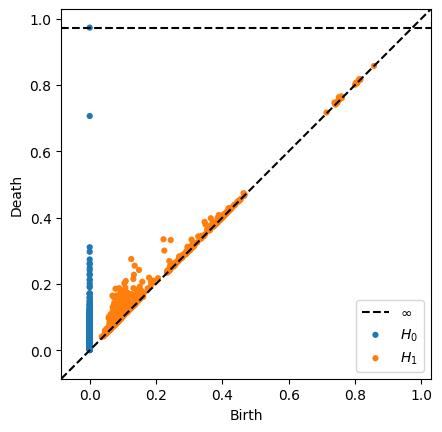

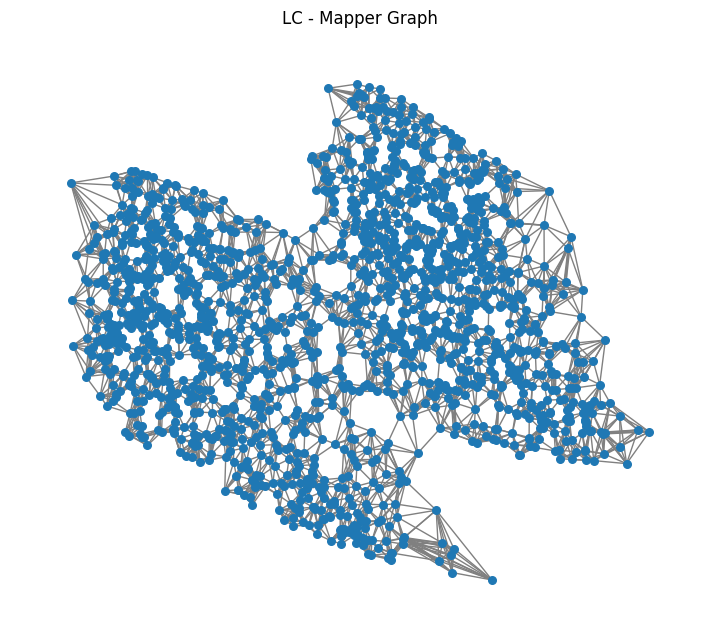

Analyzing NE activations...


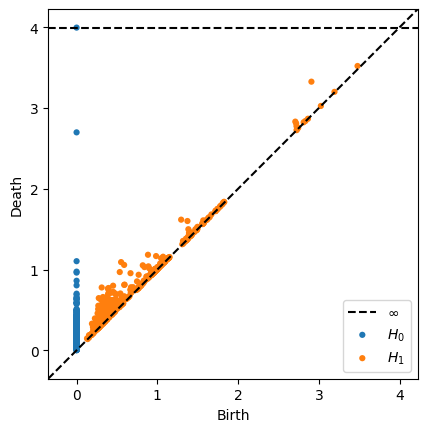

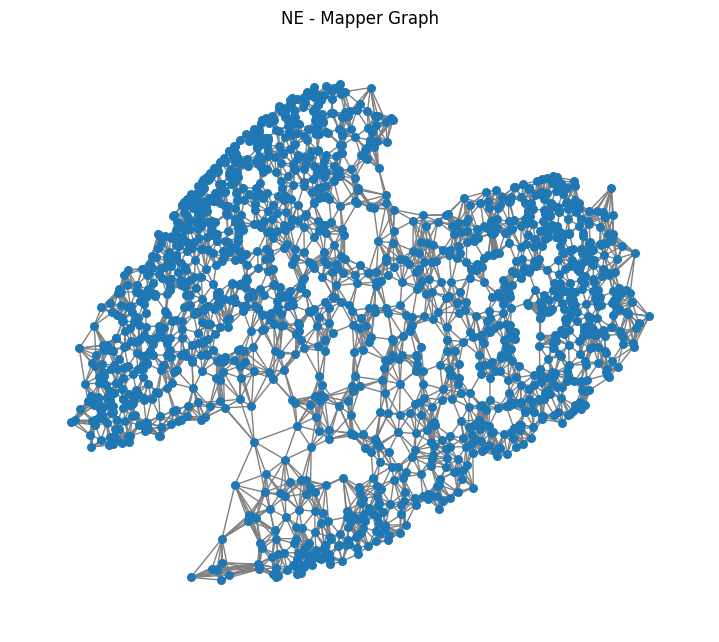

Analyzing Tonic_NE activations...


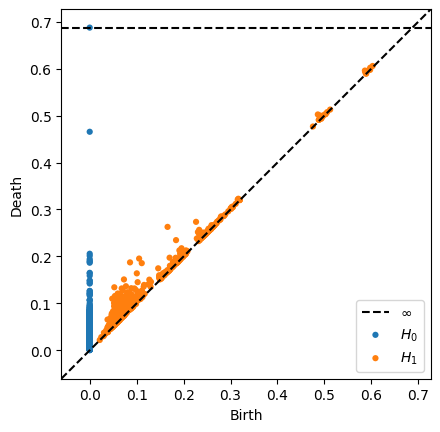

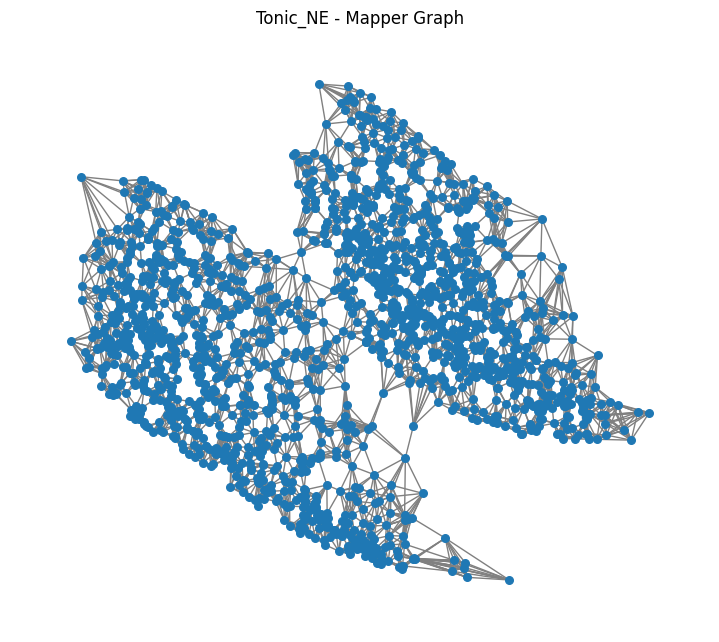

Analyzing Phasic_NE activations...


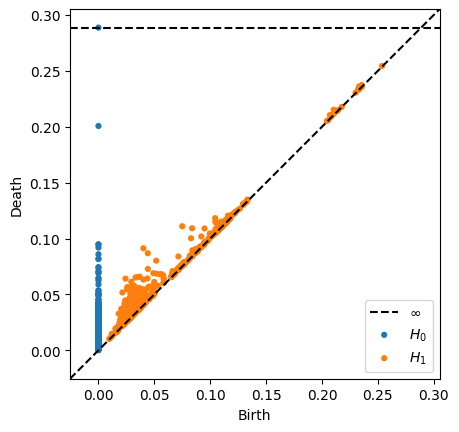

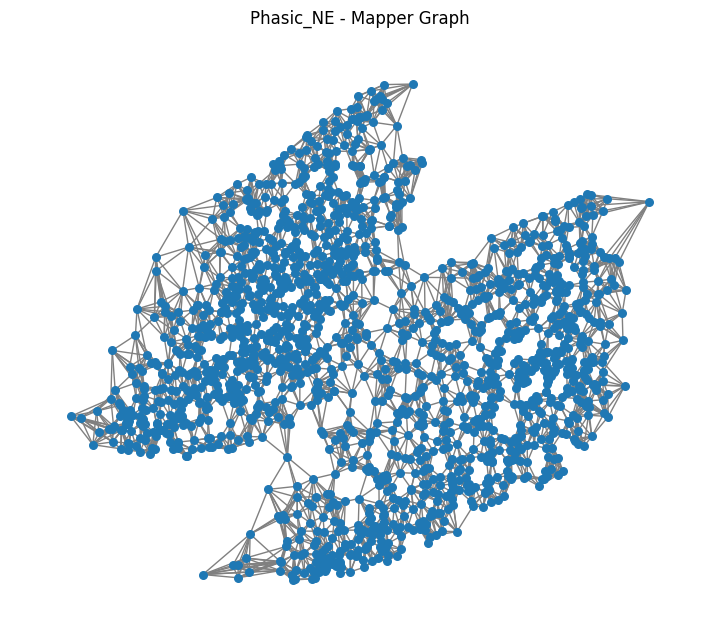

Analyzing Hidden_1 activations...


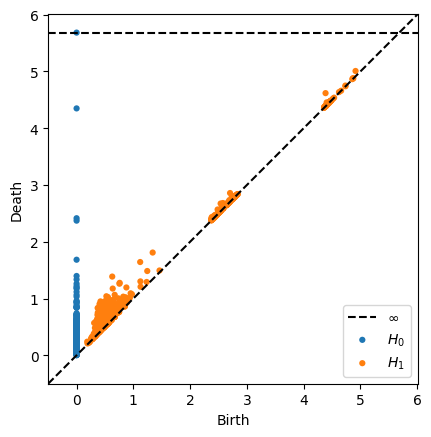

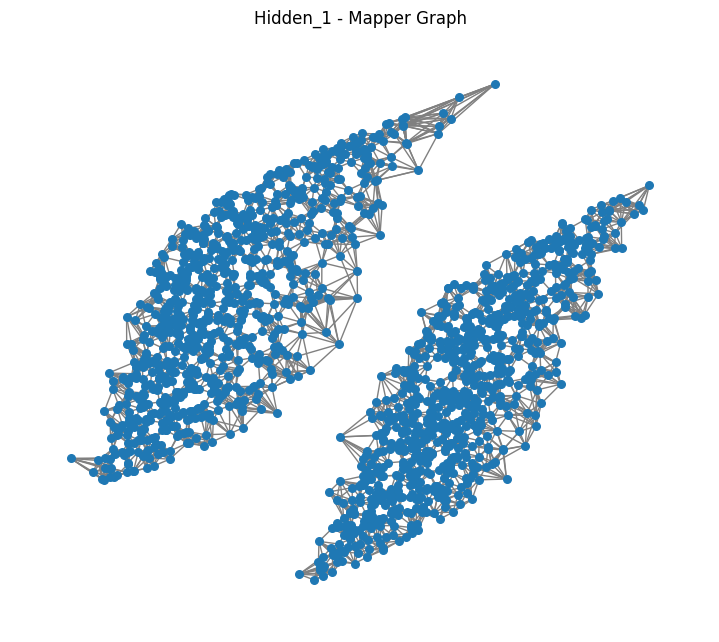

Analyzing Hidden_2 activations...


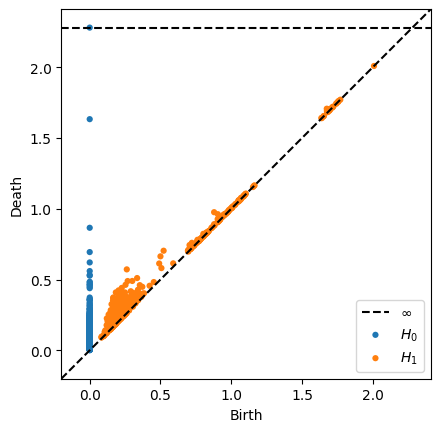

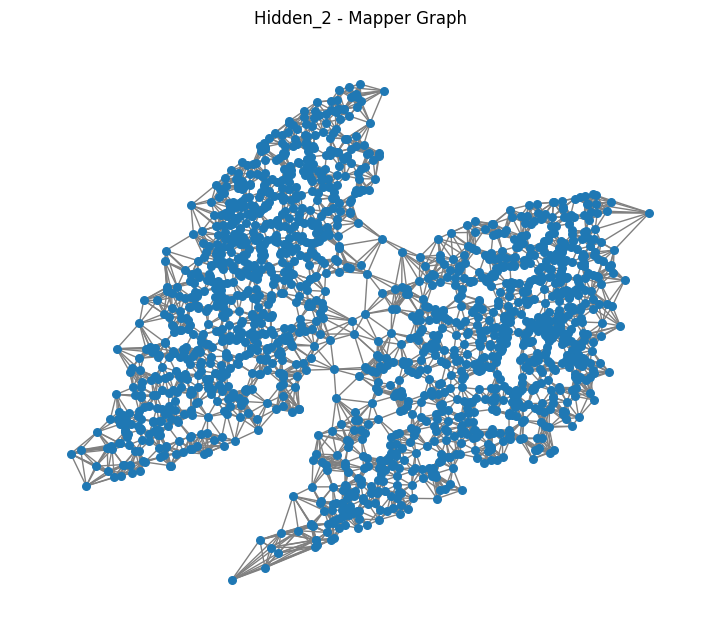

In [22]:
activations = extract_activations(ff_uncertain_gadget, X_tensor)

for key, act in activations.items():
    print(f"Analyzing {key} activations...")
    compute_persistent_homology(act, title=f"{key} - Persistent Homology")
    compute_mapper_graph(act, title=f"{key} - Mapper Graph")
